# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 62     |  |
| :-------------|:-------------|
| Student Thijn Holswilder | 6536387 |

In [81]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['naam1', 'naam2','naam3']

## Opdracht 1: Planning.

| Planning Groep: XX     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1 | Tijdstip |
| Mijlpaal 2 | Tijdstip |
| groep aanwezig 1| Tijdspanne |
| groep aanwezig 2| Tijdspanne |
| Pauze 1| Tijdspanne |
| Pauze 2| Tijdspanne |

## Opdracht 2: Import libs.

In [82]:
%matplotlib inline
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [62]
<img src="opstelling-kalibreren-subwoofer.jpeg" width="400">

a = 0.0339 ± 0.0002
b = -0.04 ± 0.24


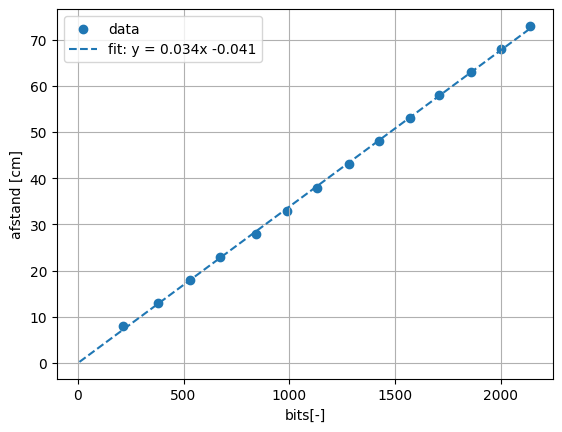

In [83]:
# Data
afstand = (90 - np.array([82, 77, 72, 67, 62, 57, 52, 47, 42, 37, 32, 27, 22, 17]))  # [cm]
bits = np.array([215, 380, 532, 673, 845, 988, 1133, 1284, 1423, 1570, 1707, 1860, 2000, 2140])

# Lineair model
def f(x, a, b):
    return a*x + b

# Fit
popt, pcov = curve_fit(f, bits, afstand)

a, b = popt
ua, ub = np.sqrt(np.diag(pcov))

print(f"a = {a:.4f} ± {ua:.4f}")
print(f"b = {b:.2f} ± {ub:.2f}")

# Fijne x voor plot
x_fit = np.linspace(min(afstand), max(bits), 100)
y_fit = f(x_fit, a, b)

# Plot
plt.figure()
plt.scatter(bits, afstand, label="data")
plt.plot(x_fit, y_fit, '--', label=f"fit: y = {a:.3f}x {b:.3f}")
plt.xlabel("bits[-]")
plt.ylabel("afstand [cm]")
plt.legend()
plt.grid()
plt.show()

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0   0  40   0  30  41
1   0  30   0  20  41
2  40   0  30   0  41
3  30   0  20   0  41


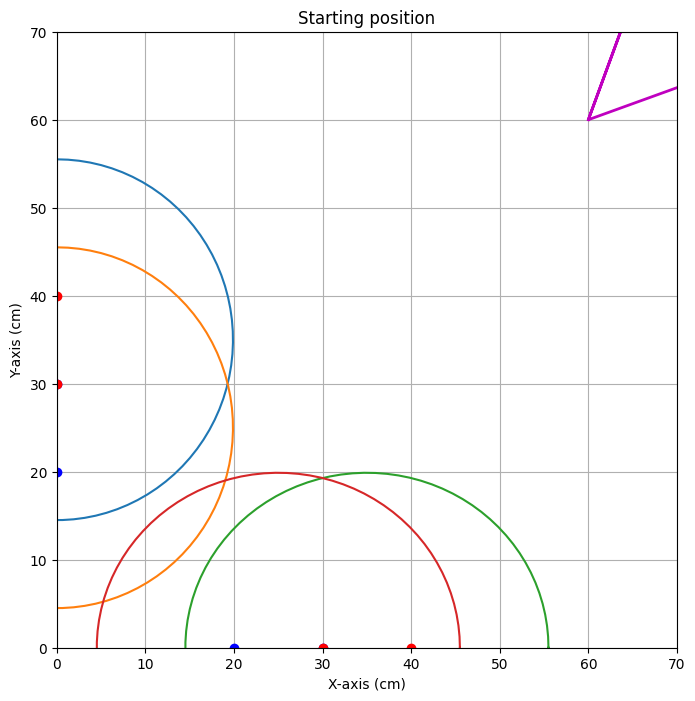


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=100.955


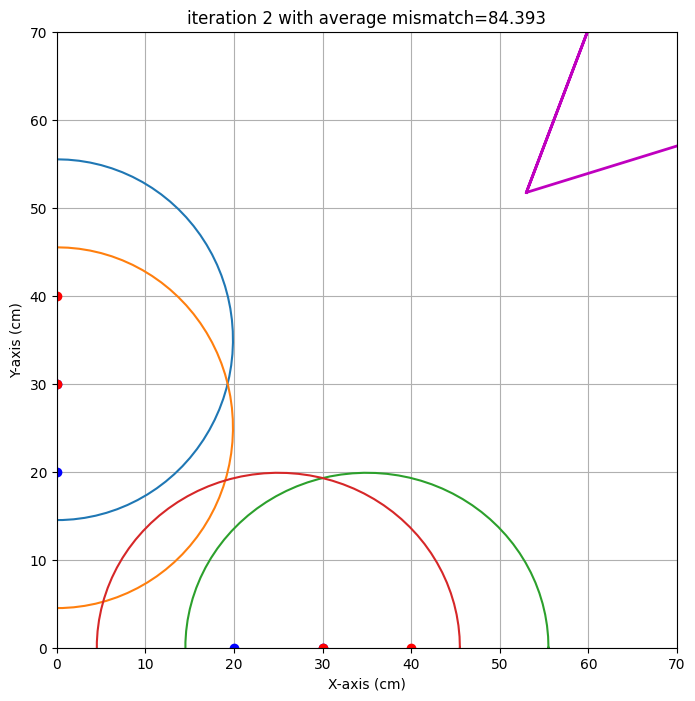

end iteration 2 with average mismatch=84.393


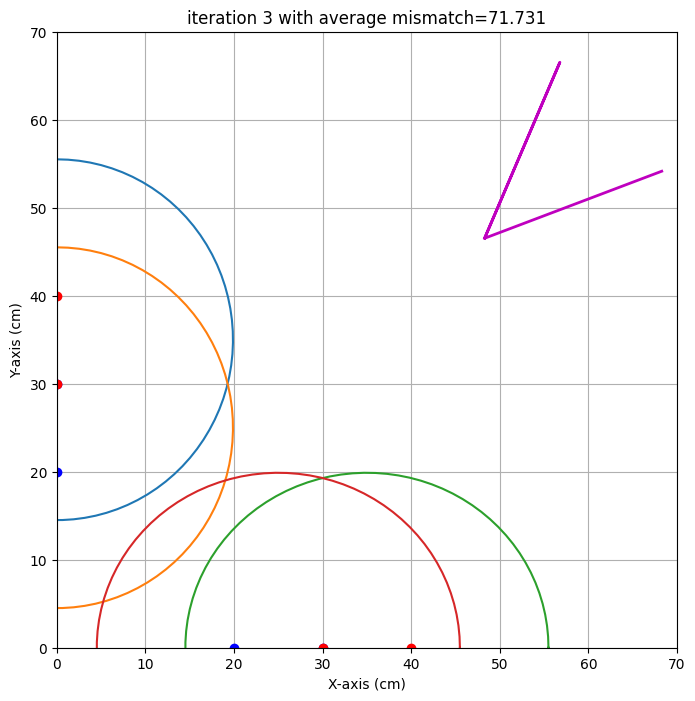

end iteration 3 with average mismatch=71.731


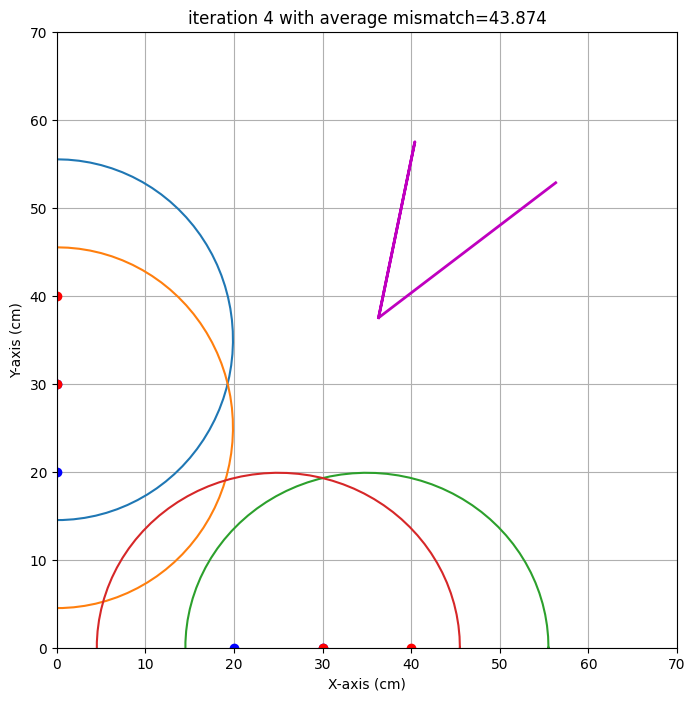

end iteration 4 with average mismatch=43.874


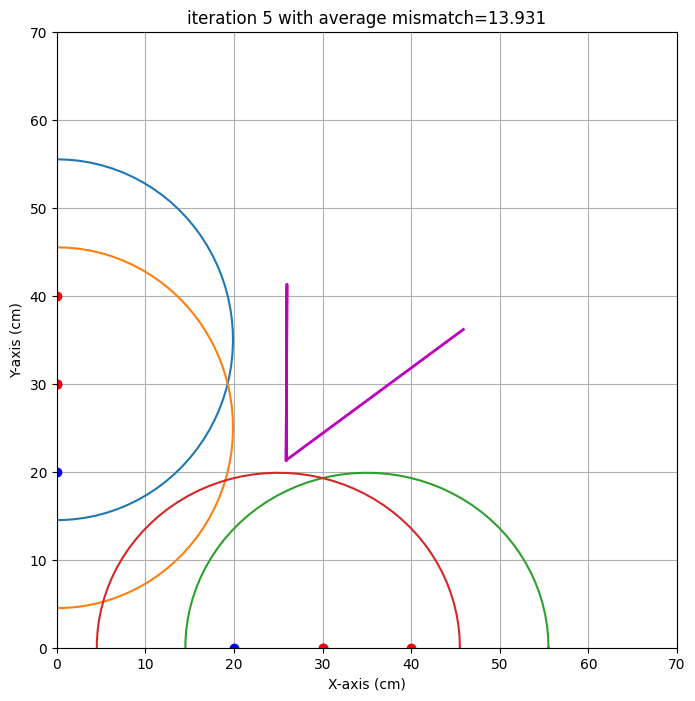

end iteration 5 with average mismatch=13.931


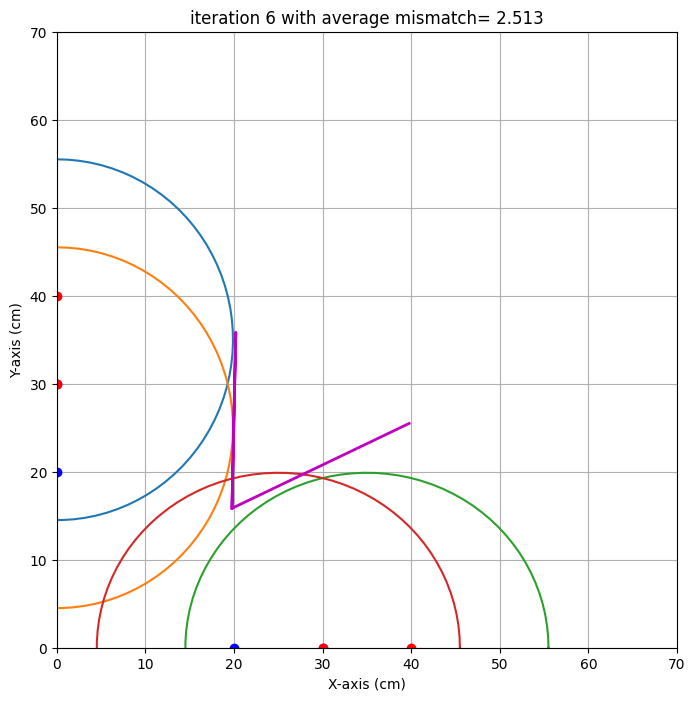

end iteration 6 with average mismatch= 2.513
end iteration 7 with average mismatch= 2.342


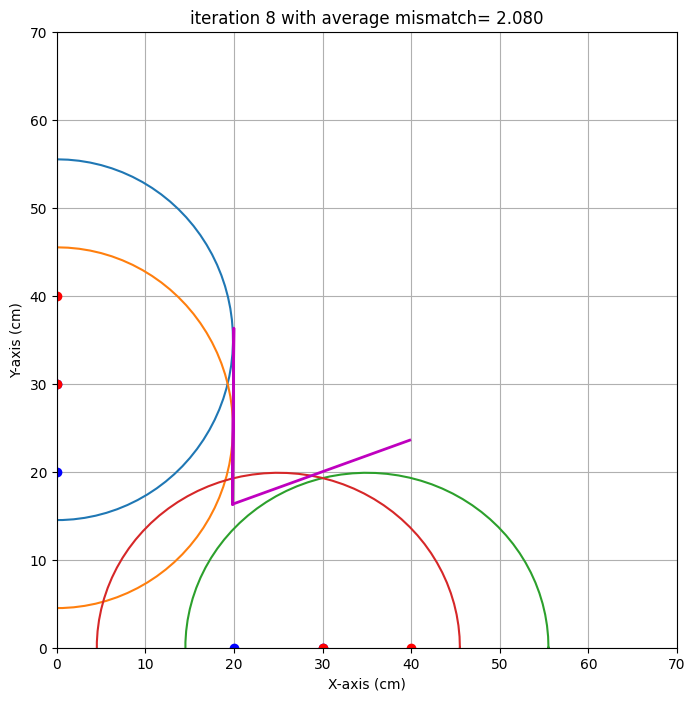

end iteration 8 with average mismatch= 2.080
end iteration 9 with average mismatch= 2.024


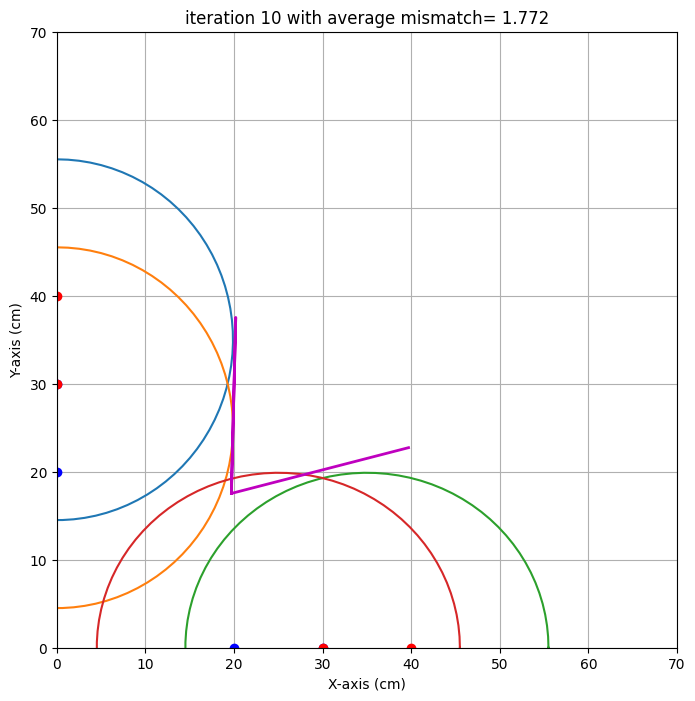

end iteration 10 with average mismatch= 1.772
end iteration 11 with average mismatch= 1.634


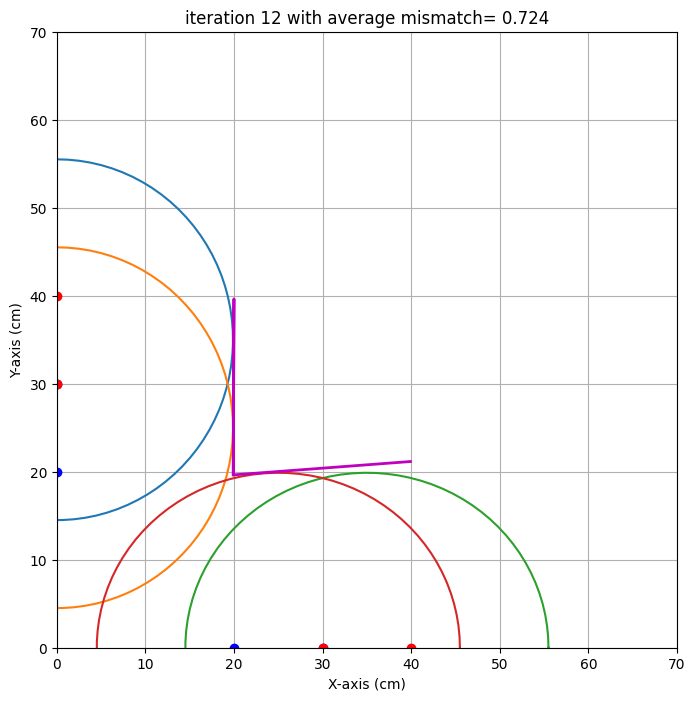

end iteration 12 with average mismatch= 0.724


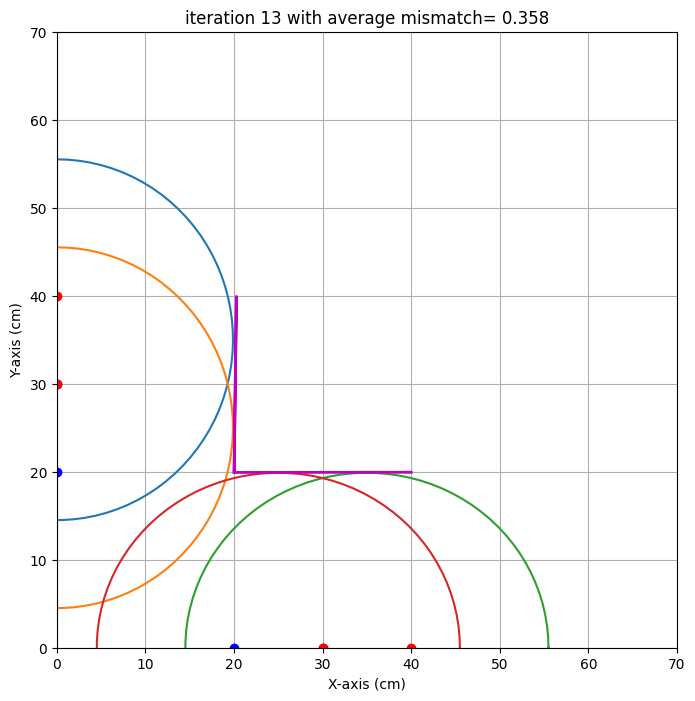

end iteration 13 with average mismatch= 0.358


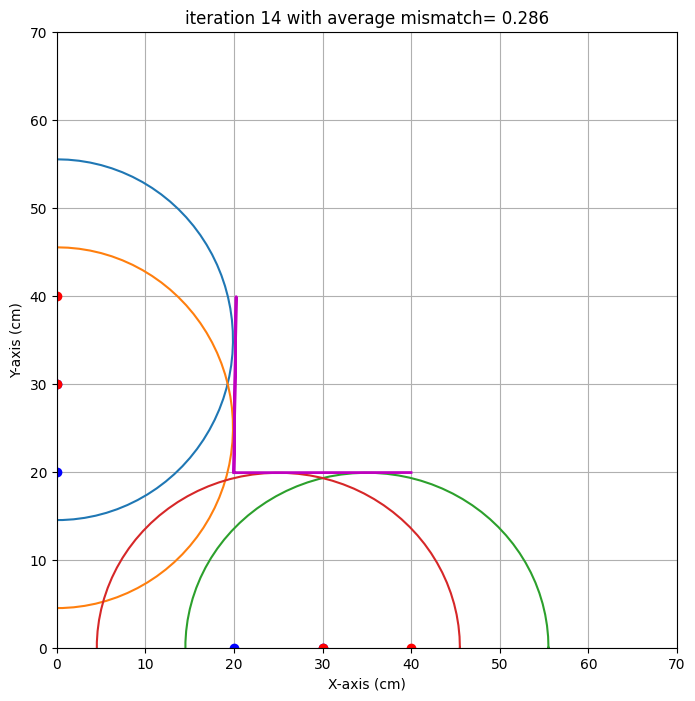

end iteration 14 with average mismatch= 0.286


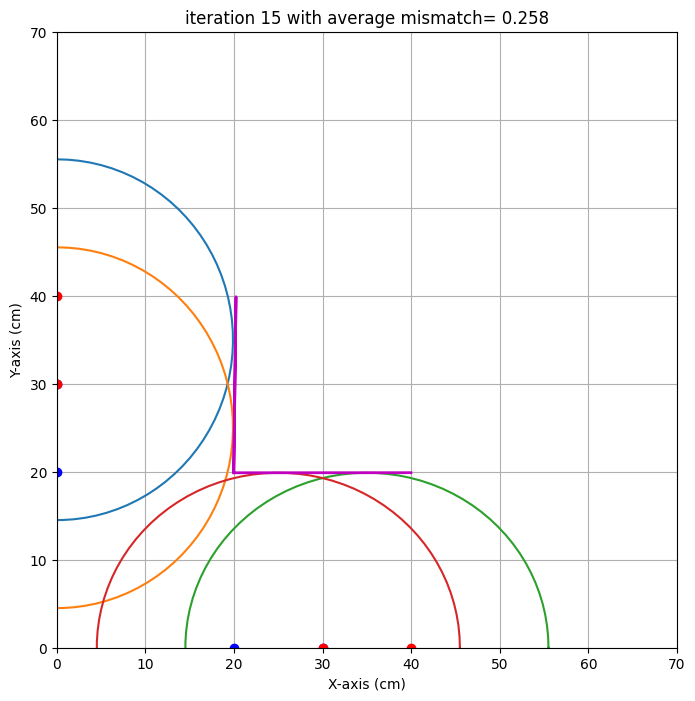

end iteration 15 with average mismatch= 0.258
end iteration 16 with average mismatch= 0.251
end iteration 17 with average mismatch= 0.251
end iteration 18 with average mismatch= 0.251
end iteration 19 with average mismatch= 0.251
end iteration 20 with average mismatch= 0.251
end iteration 21 with average mismatch= 0.251
end iteration 22 with average mismatch= 0.251
end iteration 23 with average mismatch= 0.232
end iteration 24 with average mismatch= 0.229
end iteration 25 with average mismatch= 0.228
end iteration 26 with average mismatch= 0.228
end iteration 27 with average mismatch= 0.228
end iteration 28 with average mismatch= 0.228
end iteration 29 with average mismatch= 0.228
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.228
###############################################################################
end of iteration  30
Best

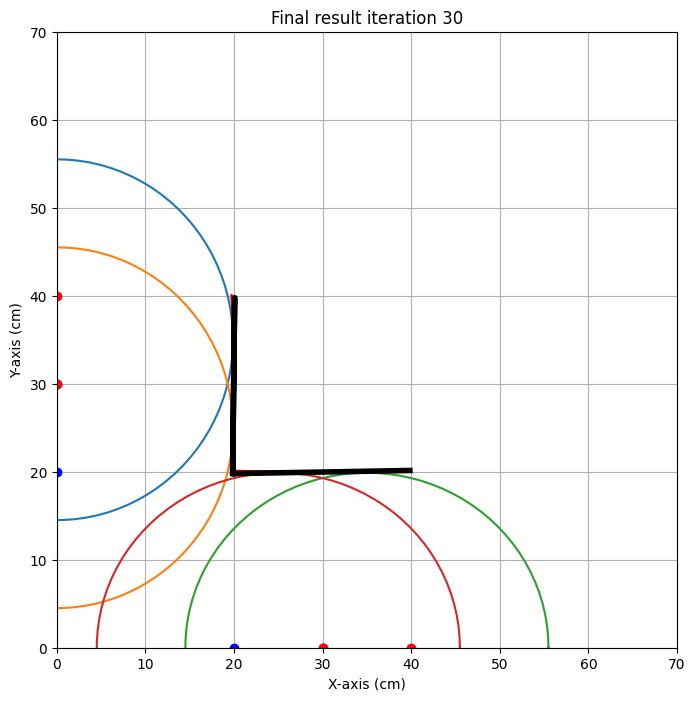

In [84]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,41],
    [0,30,0,20,41],
    #[0,10,0,20,260],
    [40,0,30,0,41],
    [30,0,20,0,41],
    #[10,0,20,0,260],
    #[10,0,0,10,260]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [85]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 19.8 cm met een standaardafwijking van 0.2 cm 
y0: 19.8 cm met een standaardafwijking van 0.3 cm 
alpha: 1.0 graden met een standaardafwijking van 1.5 graad 
beta: 0.7 graden met een standaardafwijking van 1.6 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Thijn Holswilder]
Voeg een foto in van het algoritme van het enigste groepslid
<img src="algoritme1-schets.jpeg" width="400">


## Opdracht 6: Test iteratie 0.

In [86]:
import numpy as np

threshold = 50

xr = np.arange(0, 35, 5)
xs = xr + 10
x_mid = (xr + xs) / 2

R_x = np.array([170, 170, 170, 41, 41, 41, 41]) / 2

links = 0
rechts = 40

for i in range(len(x_mid)):
    if R_x[i] < threshold:
        if x_mid[i] < rechts:
            rechts = x_mid[i]
    else:
        if x_mid[i] > links:
            links = x_mid[i]

x0 = (links + rechts) / 2
print("x0 =", x0)



yr = np.arange(0, 30, 5) 
ys = yr + 10
y_mid = (yr + ys) / 2

R_y = np.array([170, 170, 170, 41, 41, 41, 41]) / 2

onder = 0
boven = 40

for i in range(len(y_mid)):
    if R_y[i] < threshold:
        if y_mid[i] < boven:
            boven = y_mid[i]
    else:
        if y_mid[i] > onder:
            onder = y_mid[i]

y0 = (onder + boven) / 2
print("y0 =", y0)

import numpy as np

R_alpha =  41 /2
R_beta =   41 /2

x_max = 40
y_max = 40

alpha = np.rad2deg(np.arctan((R_alpha - y0) / (y_max - x0)))
beta  = np.rad2deg(np.arctan((R_beta  - x0) / (x_max - y0)))

print("alpha =", alpha)
print("beta =", beta)


x0 = 17.5
y0 = 17.5
alpha = 7.594643368591445
beta = 7.594643368591445


In [ ]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0': 20,  #zelf aanvullen,
           'y0': 20,  #zelf aanvullen,
           'alpha' : 0, #zelf aanvullen,
           'beta' : 0 #zelf aanvullen},
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Thijn Holswilder' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
            # [10,0,0,0,170],
            # [15,0,5,0,170],
            # [20,0,10,0,170],
            [25,0,15,0,41],
            [30,0,20,0,41],
            [35,0,25,0,41],
            [40,0,30,0,41],

            # [0,10,0,0,170],
            # [0,15,0,5,170],
            # [0,20,0,10,170],
            [0,25,0,15,41],
            [0,30,0,20,41],
            [0,35,0,25,41],
            [0,40,0,30,41]
        ]
)
}

## Opdracht 7: Evaluatie.

Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0  25   0  15   0  41
1  30   0  20   0  41
2  35   0  25   0  41
3  40   0  30   0  41
4   0  25   0  15  41
5   0  30   0  20  41
6   0  35   0  25  41
7   0  40   0  30  41


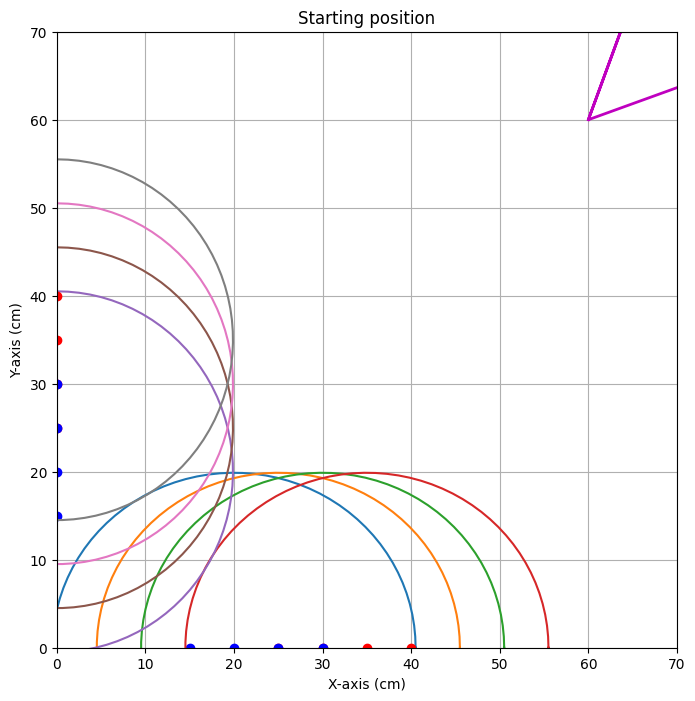


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=103.381


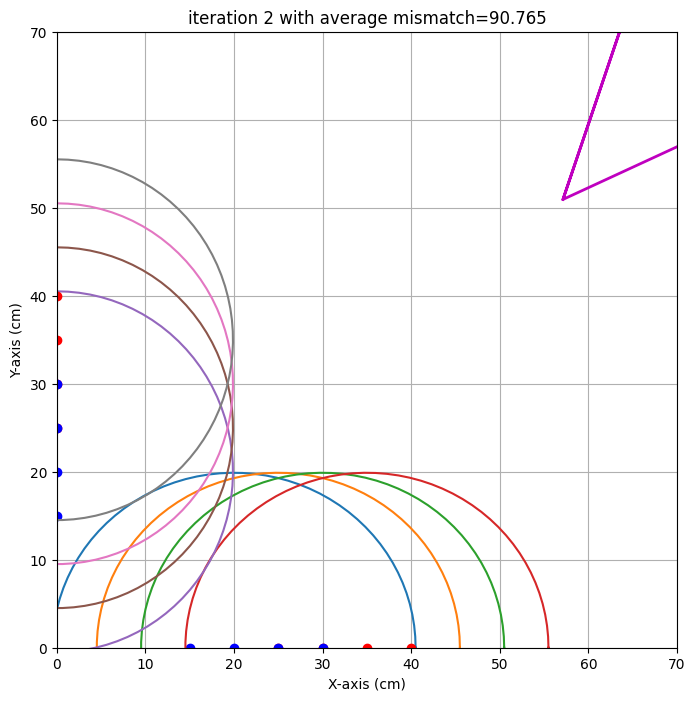

end iteration 2 with average mismatch=90.765


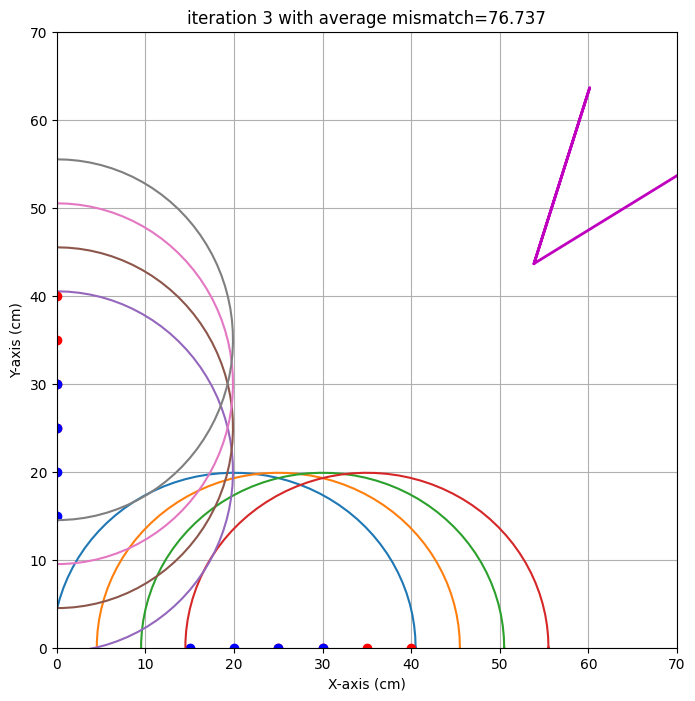

end iteration 3 with average mismatch=76.737


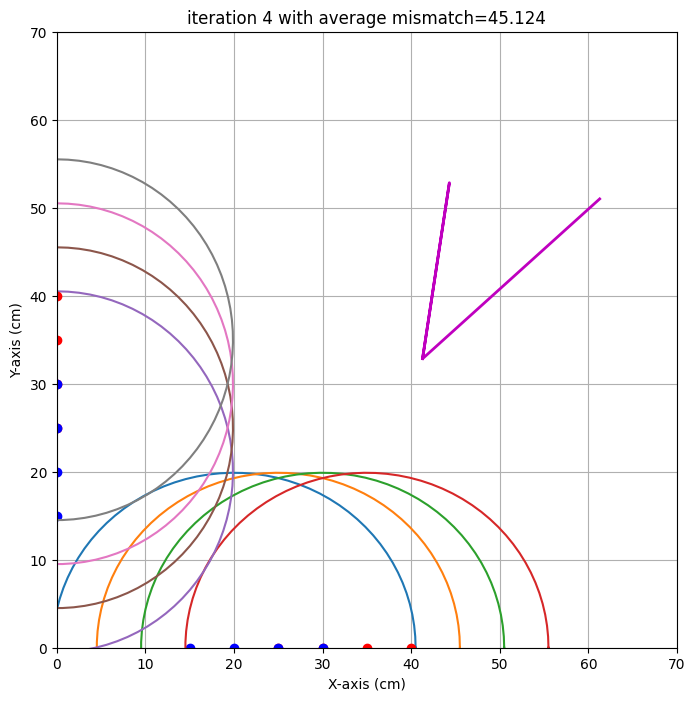

end iteration 4 with average mismatch=45.124


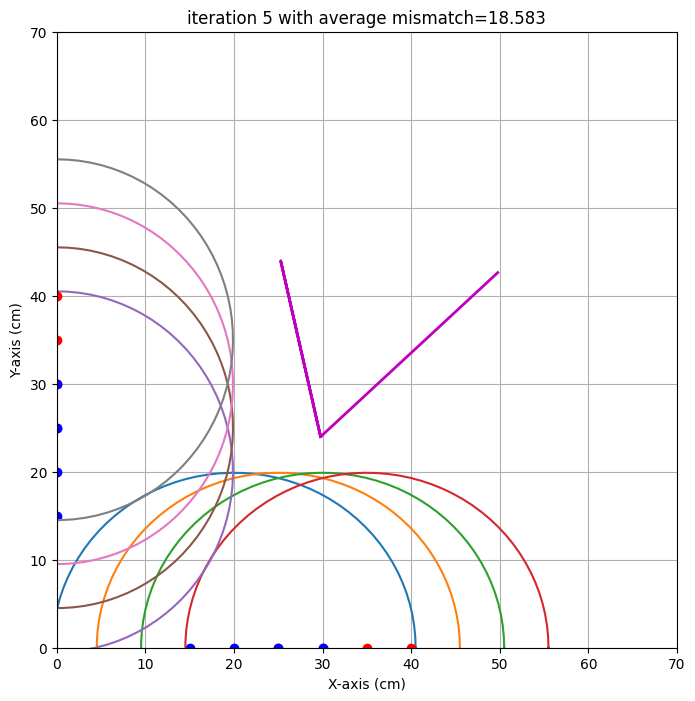

end iteration 5 with average mismatch=18.583


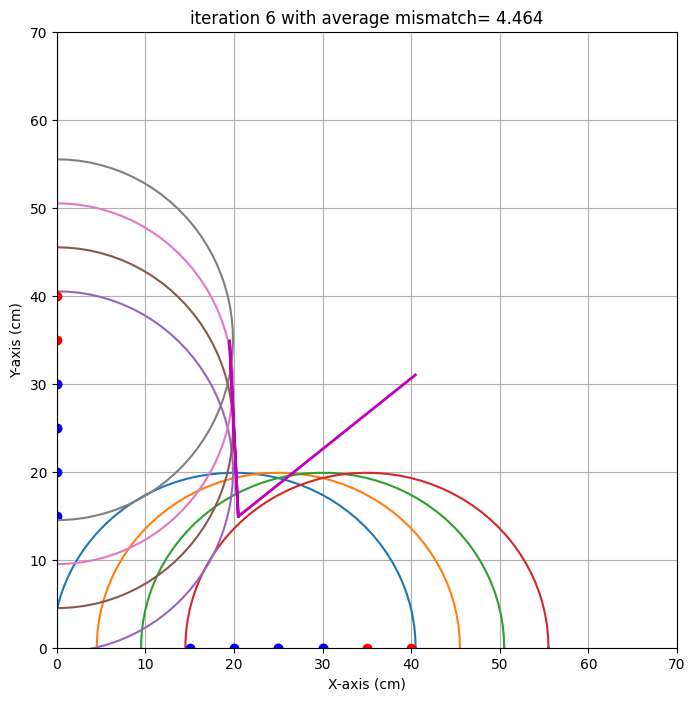

end iteration 6 with average mismatch= 4.464


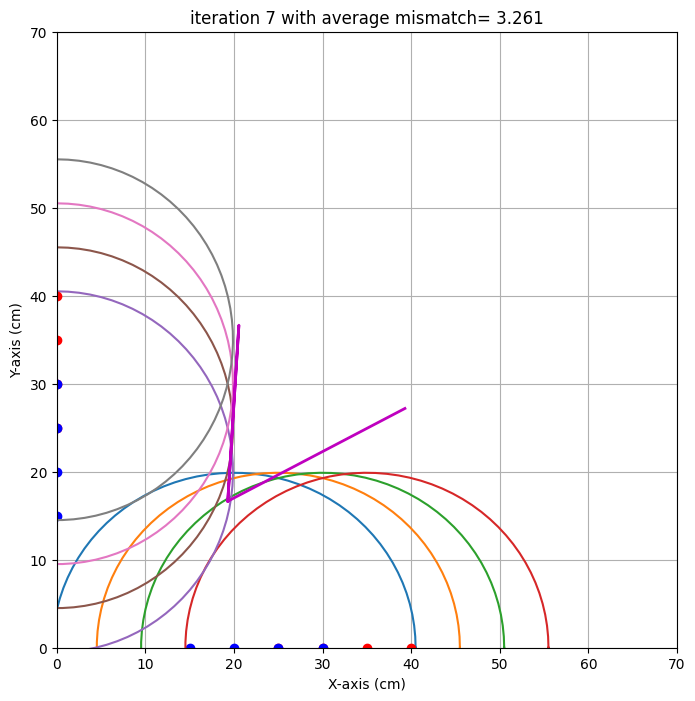

end iteration 7 with average mismatch= 3.261


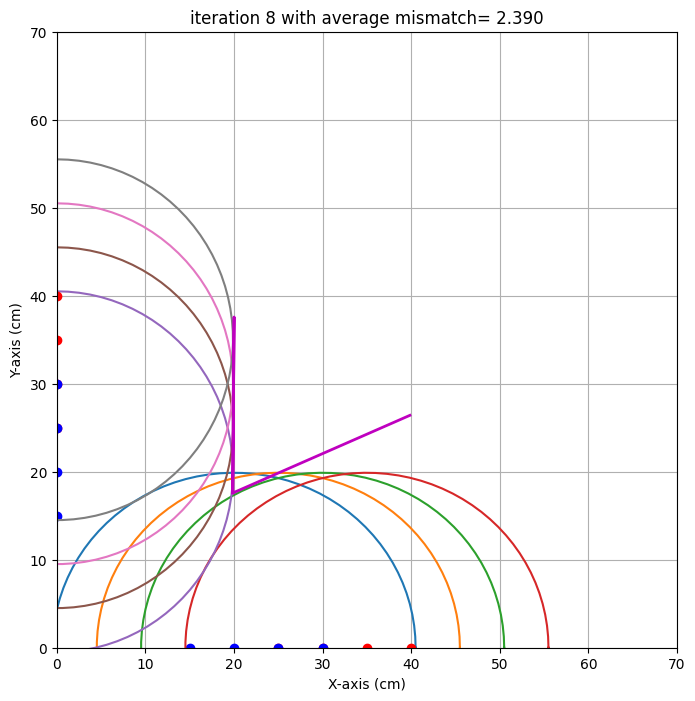

end iteration 8 with average mismatch= 2.390
end iteration 9 with average mismatch= 2.381


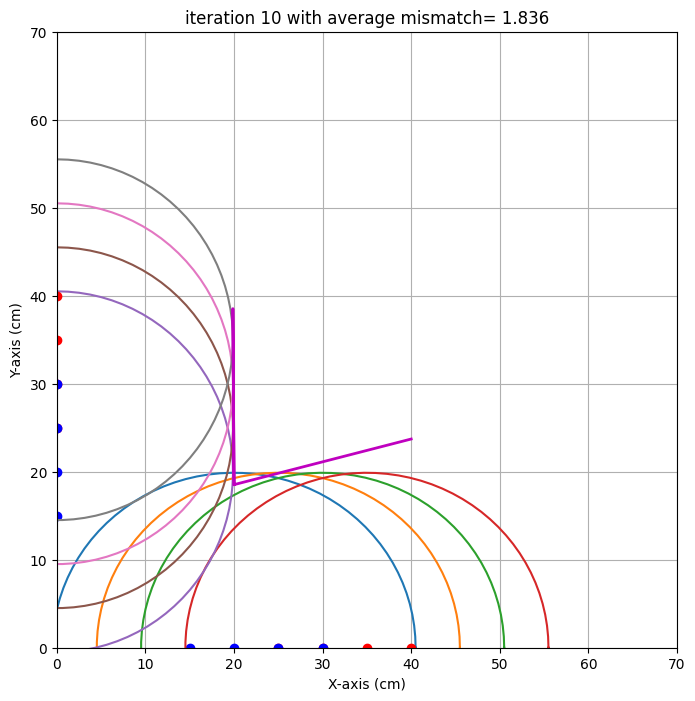

end iteration 10 with average mismatch= 1.836


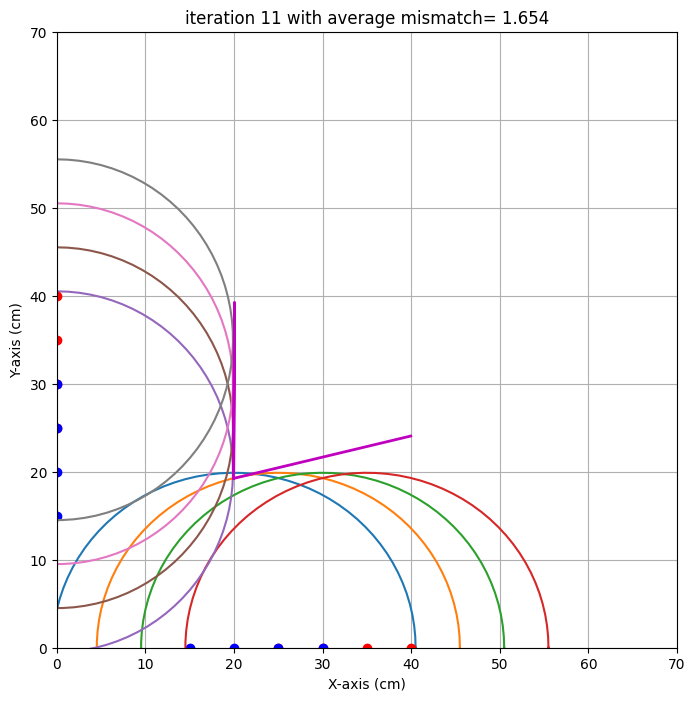

end iteration 11 with average mismatch= 1.654
end iteration 12 with average mismatch= 1.582


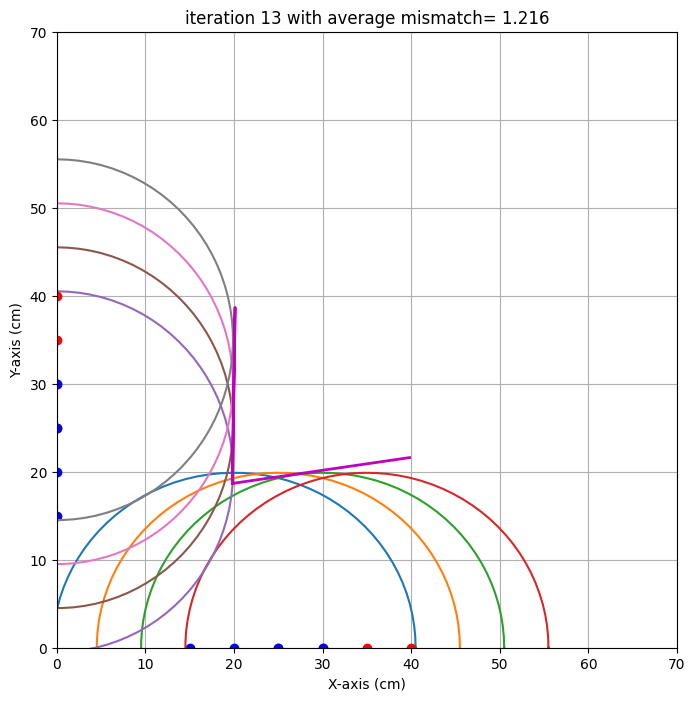

end iteration 13 with average mismatch= 1.216
end iteration 14 with average mismatch= 1.168
end iteration 15 with average mismatch= 1.088


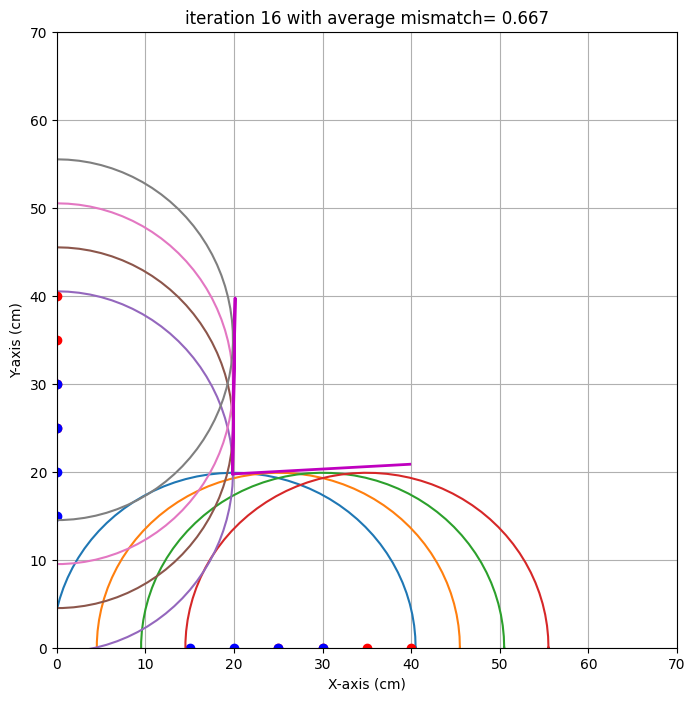

end iteration 16 with average mismatch= 0.667


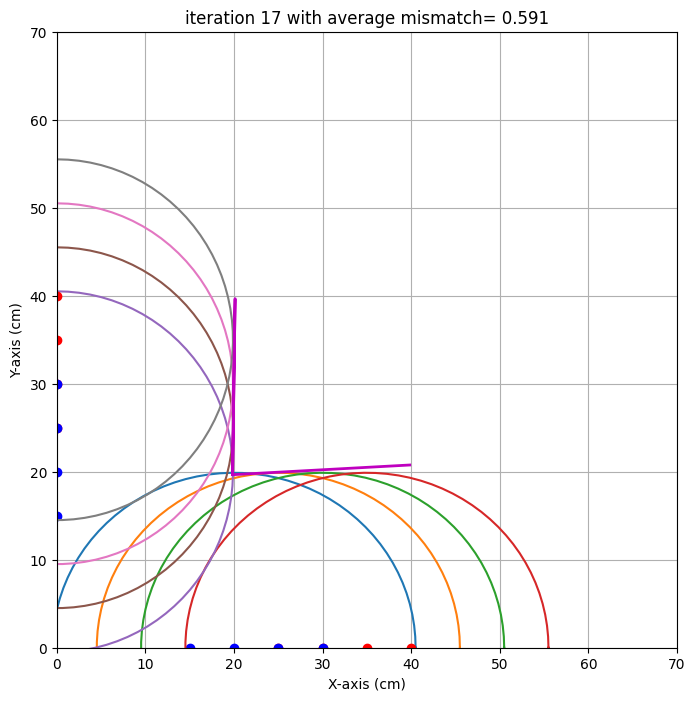

end iteration 17 with average mismatch= 0.591


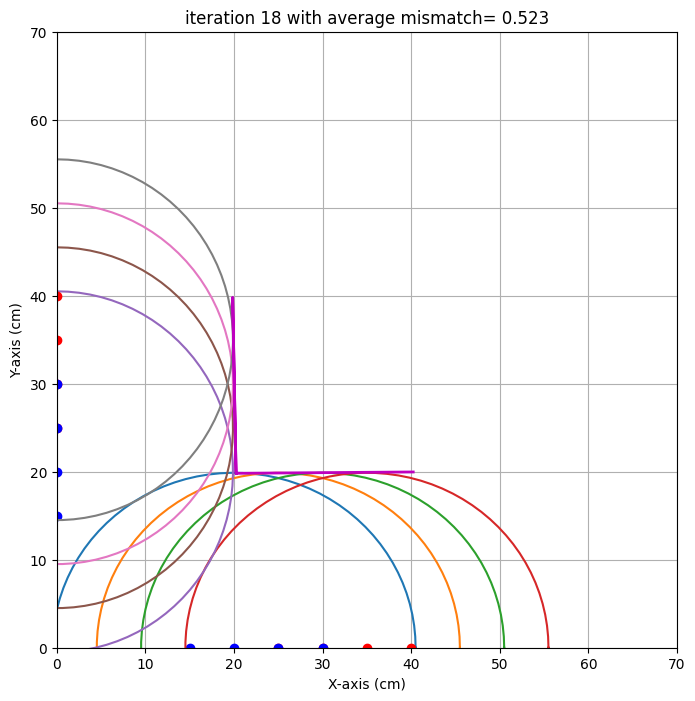

end iteration 18 with average mismatch= 0.523
end iteration 19 with average mismatch= 0.522
end iteration 20 with average mismatch= 0.522
end iteration 21 with average mismatch= 0.522
end iteration 22 with average mismatch= 0.522
end iteration 23 with average mismatch= 0.522
end iteration 24 with average mismatch= 0.522
end iteration 25 with average mismatch= 0.522
end iteration 26 with average mismatch= 0.522
end iteration 27 with average mismatch= 0.522
end iteration 28 with average mismatch= 0.522
end iteration 29 with average mismatch= 0.522
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.522
###############################################################################
end of iteration  30
Best alpha=   0.44 with uncertainty=   3.56
Best beta =  -1.11 with uncertainty=   2.15
Best x0   =  20.23 with uncertainty=   0.33
Best y0   =  19.82 with uncertainty=   0.92
################

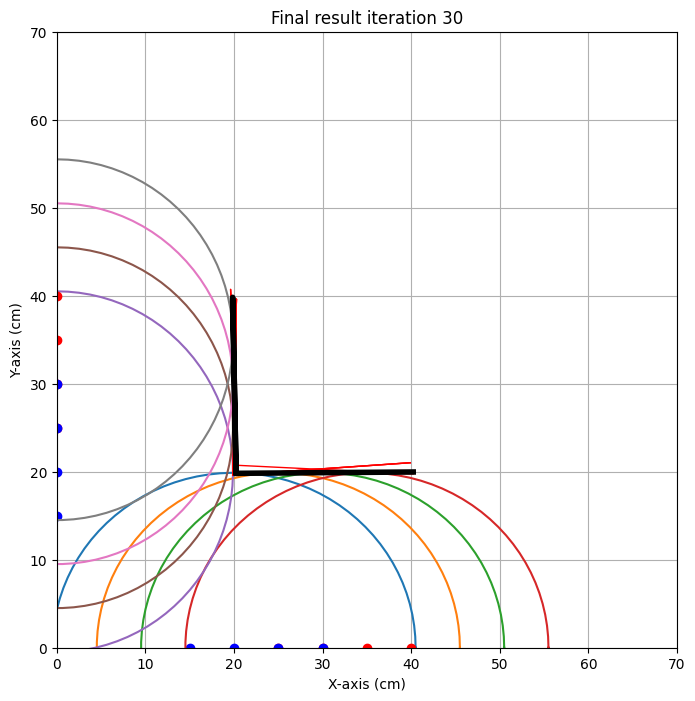

{'alpha': np.float64(0.4352552904674476), 'alpha_eps': np.float64(3.5563120493427296), 'beta': np.float64(-1.107121294612216), 'beta_eps': np.float64(2.153707608494865), 'x0': np.float64(20.229607282491788), 'x0_eps': np.float64(0.3286308418429513), 'y0': np.float64(19.81800058169898), 'y0_eps': np.float64(0.9186548429685537)}


In [ ]:
# Hier runnen we het imaging algoritme:

resultaat = imagingDEF.imagingDEF(data['Thijn Holswilder'])
print(resultaat)


In [ ]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

## Opdracht 8: Iteratie1+.VERVANG DEZE TEKST DOOR DE TIJD WANNEER JE AAN DEZE ITERATIE BEGINT.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](tudelftLogo.png)


In [ ]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

In [113]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0': 20,  #zelf aanvullen,
           'y0': 20,  #zelf aanvullen,
           'alpha' : 0, #zelf aanvullen,
           'beta' : 0 #zelf aanvullen},
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Thijn Holswilder' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # --- vanaf onder (y = 0) ---
    [10,0,20,20,41],
    [15,0,25,20,41],
    [20,0,30,20,41],
    [25,0,35,20,41],
    [30,0,40,20,41],
    [35,0,45,20,41],
    [40,0,50,20,41],
    # [5,0,10,20,ongeldig],

    # --- vanaf links (x = 0) ---
    [0,10,20,20,41],
    [0,15,20,25,41],
    [0,20,20,30,41],
    [0,25,20,35,41],
    [0,30,20,40,41],
    [0,35,20,45,41],
    [0,40,20,50,41],
    # [0,5,20,10,ongeldig],
]
)
}

Running the imaging algorithm with the following data:
    xs  ys  xr  yr   R
0   10   0  20  20  41
1   15   0  25  20  41
2   20   0  30  20  41
3   25   0  35  20  41
4   30   0  40  20  41
5   35   0  45  20  41
6   40   0  50  20  41
7    0  10  20  20  41
8    0  15  20  25  41
9    0  20  20  30  41
10   0  25  20  35  41
11   0  30  20  40  41
12   0  35  20  45  41
13   0  40  20  50  41


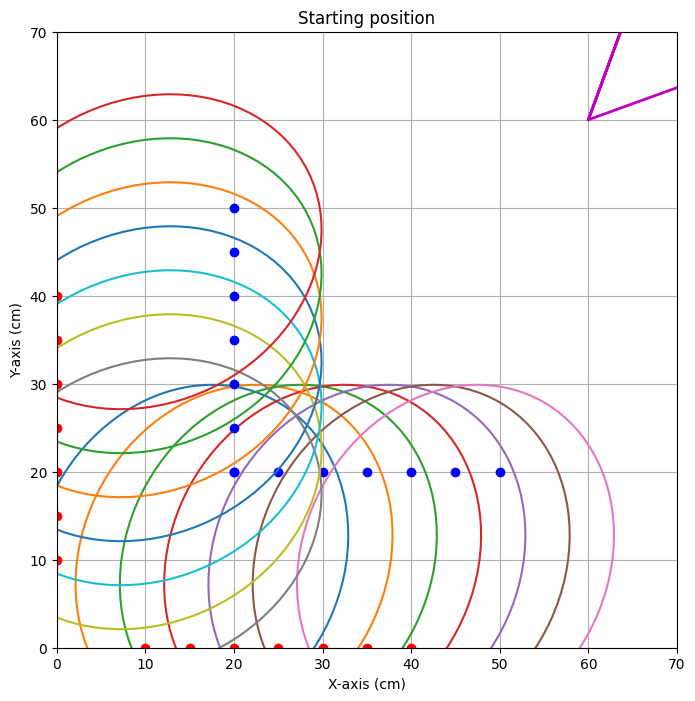


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=84.234


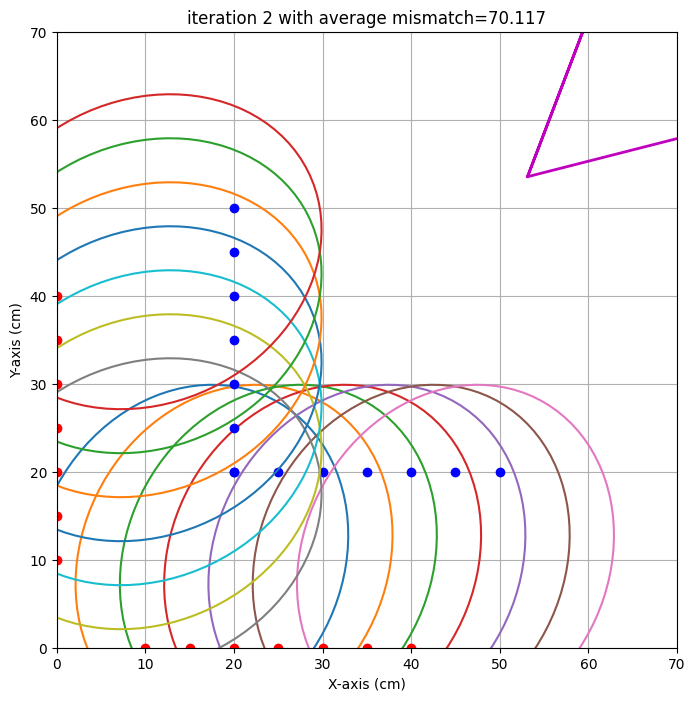

end iteration 2 with average mismatch=70.117


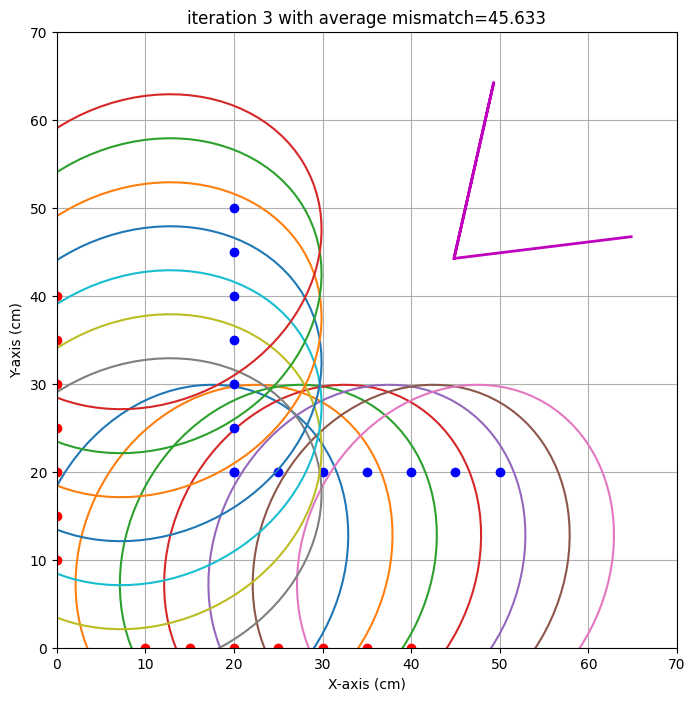

end iteration 3 with average mismatch=45.633


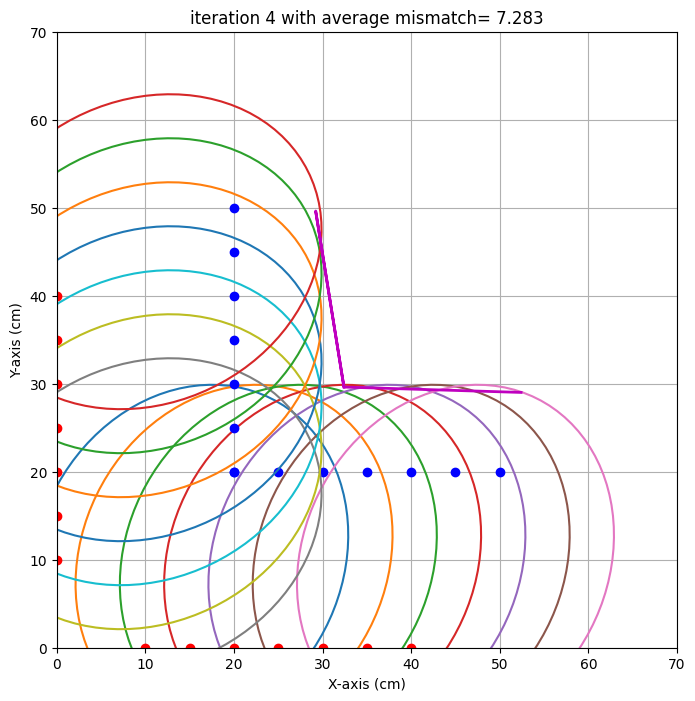

end iteration 4 with average mismatch= 7.283


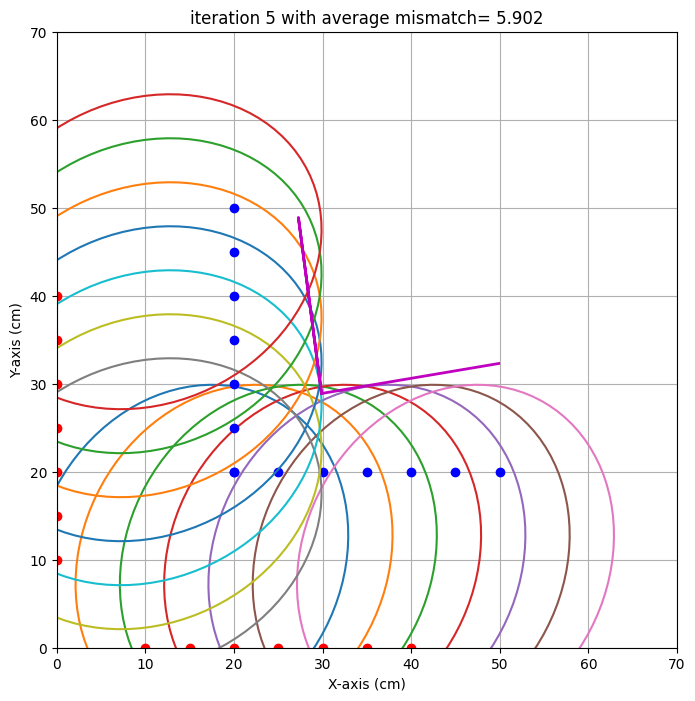

end iteration 5 with average mismatch= 5.902


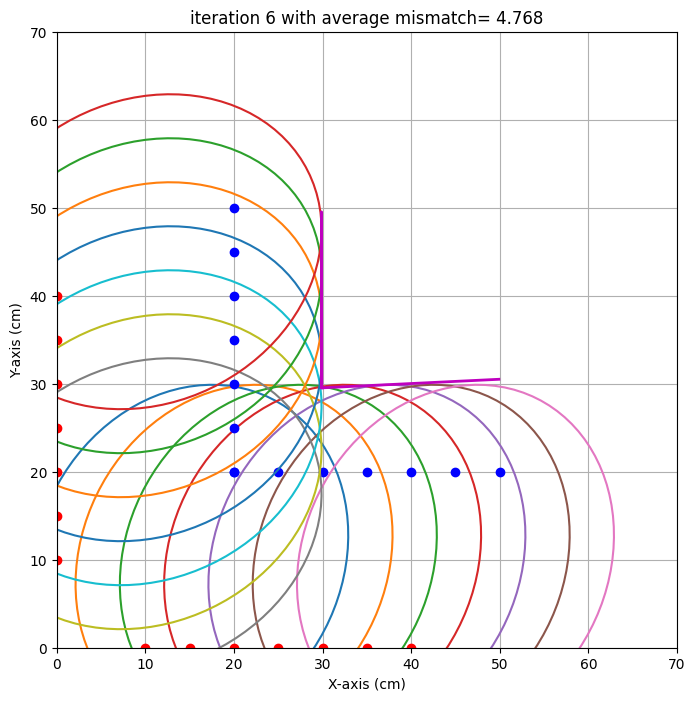

end iteration 6 with average mismatch= 4.768
end iteration 7 with average mismatch= 4.761
end iteration 8 with average mismatch= 4.757
end iteration 9 with average mismatch= 4.757
end iteration 10 with average mismatch= 4.756
end iteration 11 with average mismatch= 4.756
end iteration 12 with average mismatch= 4.756
end iteration 13 with average mismatch= 4.756
end iteration 14 with average mismatch= 4.756
end iteration 15 with average mismatch= 4.756
end iteration 16 with average mismatch= 4.756
end iteration 17 with average mismatch= 4.756
end iteration 18 with average mismatch= 4.756
end iteration 19 with average mismatch= 4.756
end iteration 20 with average mismatch= 4.756
end iteration 21 with average mismatch= 4.756
end iteration 22 with average mismatch= 4.756
end iteration 23 with average mismatch= 4.756
end iteration 24 with average mismatch= 4.756
end iteration 25 with average mismatch= 4.756
end iteration 26 with average mismatch= 4.756
end iteration 27 with average mismatch

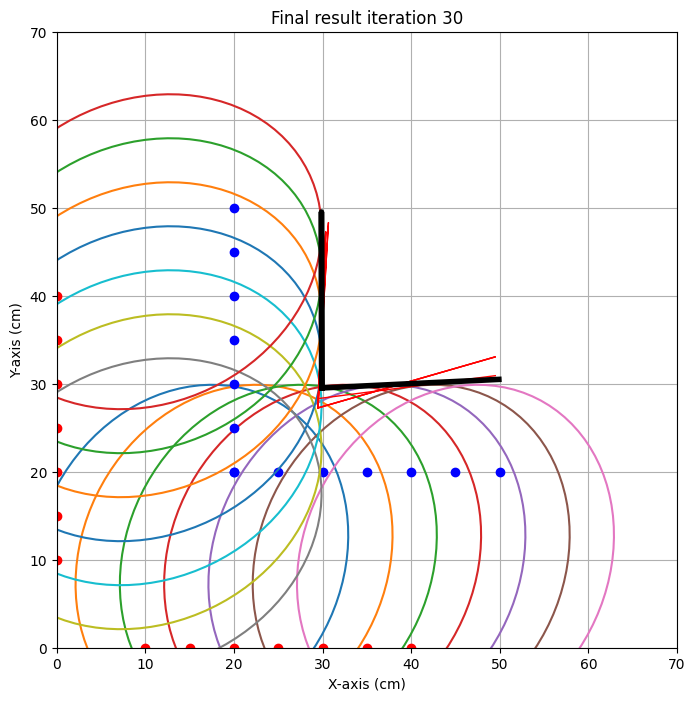

{'alpha': np.float64(2.790427295037095), 'alpha_eps': np.float64(13.372232284765921), 'beta': np.float64(-0.08503127831985725), 'beta_eps': np.float64(3.3990206795774482), 'x0': np.float64(29.897372042295686), 'x0_eps': np.float64(0.42277217243557175), 'y0': np.float64(29.517155099630337), 'y0_eps': np.float64(2.2666728418303315)}


In [114]:
resultaat = imagingDEF.imagingDEF(data['Thijn Holswilder'])
print(resultaat)

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

In [ ]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':  # zelf aanvullen,
                    'y0':  # zelf aanvullen,
                    'alpha' :  # zelf aanvullen,
                    'beta' :  # zelf aanvullen
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    # zelf aanvullen
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")